# Week 1 Lecture 2 — First Keras model (instructor demo)

Tiny binary classifier on synthetic data. Run live in Lecture 2; students watch on projector (BYOD follow-along optional).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

In [6]:
rng = np.random.default_rng(504) #固定随机种子，以后随机代码生成的是一样的，方便实现复现，还有其他的吗？rng是随机数发生器对象，后续用它生成各类随机数据
n = 400
X = rng.normal(size=(n, 4)) #normal标准正态分布随机数，均值0，方差1；数组形状（400，4）400个样本（行），4列
X #特征矩阵，浮点数数组（二维）全体样本，x小写，单个样本
y = (X[:, 0] + X[:, 1] - 0.5 * X[:, 2] > 0).astype("float32") #z=x0 + x1 - 0.5x2 判断是否大于0，返回一个布尔值，转换成浮点数数组（True-1.0; false-0.0； 第4个特征无效
print("X shape:", X.shape) #输出（400，4）400个样本，4列特征
print("y shape:", y.shape) #输出（400，）一堆标签数组，每个样本对应0/1个标签
print("Positive class rate:", y.mean()) #正样本占比（1的数量/总样本400）

X shape: (400, 4)
y shape: (400,)
Positive class rate: 0.4725


In [7]:
model = keras.Sequential([ #第一段：搭建神经网络模型：sequential搭建顺序堆叠式神经网络，层从上到下以此执行，适合简单线性网络
    layers.Input(shape=(4,)), #输入层，输入4维特征，对应前面4列
    layers.Dense(16, activation="relu"), #全连接层，输入16个神经元，激活函数relu
    layers.Dense(1, activation="sigmoid"), #输出层，输入1个神经元，激活函数sigmoid，适配二分配任务:输出值代表预测为正类的概率
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile( #第二段：编译模型+训练
    optimizer="adam", #自适应梯度优化器，自动调整学习率，收敛速度快，深度学习通用选择
    loss="binary_crossentropy", #二分类交叉熵损失，适合二分类任务，衡量预测概率与真实0/1标签的差距
    metrics=["accuracy"], #评估指标，准确率，训练时额外计算并输出准确率，方便观察分类效果
)
history = model.fit(X, y, epochs=10, batch_size=32,verbose=1) #verbose每一轮的loss、accuracy

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.9700 - loss: 0.1996
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.9700 - loss: 0.1917
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.9700 - loss: 0.1845
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.9725 - loss: 0.1780
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.9750 - loss: 0.1717
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.9775 - loss: 0.1659
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9800 - loss: 0.1606
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - accuracy: 0.9800 - loss: 0.1555
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.9800 - loss: 0.1507
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.9800 - loss: 0.1461


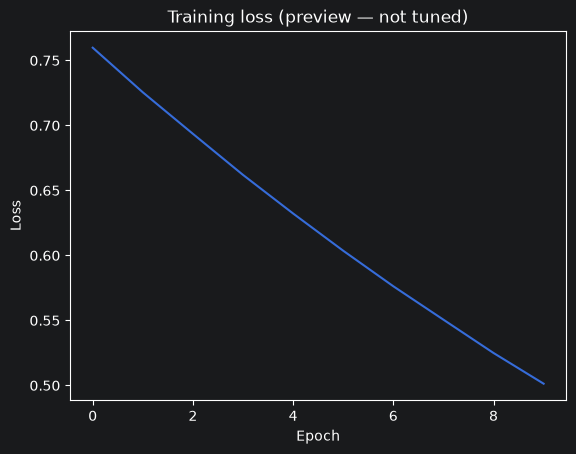

In [9]:
plt.plot(history.history["loss"]) #第三段：绘制训练损失曲线，取出每一轮训练集损失值列表
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss (preview — not tuned)") #没有调参
plt.show()

1. 用 np.random 生成 400 样本、4 特征人工二分类数据集 X,y
2. 搭建小型全连接神经网络做二分类预测
3. 配置二分类专用损失与优化器，训练 10 轮
4. 可视化训练损失，查看模型收敛情况